# RVC 1, Ch 2.2 — 3D Position and Orientation

Python consolidation of **`02_rvc1_ch2.2_3DPos.mlx`** using the strongest material from the older notebooks `3.6`, `3.7`, `3.8`, `3.11`, `3.12`, and `3.13`.

This notebook follows the MATLAB live-script teaching sequence and uses the **Spatial Math Toolbox for Python**.

References:
- Python Robotics ecosystem: https://pythonrobotics.io/
- Spatial Math Toolbox for Python: https://spatialmath-python.rai-inst.com/

### MATLAB → Python conventions used here
- MATLAB matrix multiplication `*` becomes NumPy matrix multiplication `@` for raw arrays.
- Spatial Math objects (`SO3`, `SE3`, `UnitQuaternion`) compose with `*`.
- Rotation matrices are 3×3; homogeneous rigid-body transforms are 4×4.
- Python/NumPy vectors are normally 1D arrays, unlike MATLAB column vectors.
- For products applied to column vectors, the **rightmost transformation acts first**.


In [ ]:
# Notebook setup
# Interactive 3D plotting is preferable. If ipympl is unavailable, fall back to inline plots.
try:
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception:
    get_ipython().run_line_magic('matplotlib', 'inline')

import numpy as np
import matplotlib.pyplot as plt
from math import pi

from spatialmath import SO3, SE3, UnitQuaternion
from spatialmath.base import (
    rotx, roty, rotz,
    trotx, troty, trotz,
    r2t, trplot,
    eul2r, tr2eul,
    rpy2r, tr2rpy,
    tr2angvec, angvec2r,
)

np.set_printoptions(precision=5, suppress=True, linewidth=120)
plt.close('all')


def new_3d_axes(dims=(-1.5, 1.5), elev=25, azim=45):
    """Create a consistent 3D axis for coordinate-frame visualizations."""
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')
    lo, hi = dims
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_zlim(lo, hi)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)
    ax.grid(True)
    return fig, ax


## Lec 03.6 (Ch 2.2) — 3D Rotations

Let's begin by creating a reference **world frame** that will not move. For a pure rotation representation, the identity matrix is the world orientation.


In [ ]:
W = np.eye(3)
print(W)

Poses/orientations can be visualized with `trplot`. Here `{W}` is the fixed reference frame.

In [ ]:
fig, ax = new_3d_axes()
trplot(W, frame='{W}', color='c', ax=ax)
plt.show()


Now let's compute specific 3D rotations. Start with a rotation about the **x-axis** by $\pi/4$ radians.

In [ ]:
rx = rotx(pi/4)
print(rx)

Visualize the rotated local frame together with the fixed world frame. With an interactive Matplotlib backend you can rotate the 3D view with the mouse.

In [ ]:
fig, ax = new_3d_axes()
trplot(W, frame='{W}', color='c', ax=ax)
trplot(rx, frame='{rx}', color='r', ax=ax)
plt.show()


A rotation about the **y-axis**, this time specified in degrees:

In [ ]:
ry = roty(45, unit='deg')
print(ry)

In [ ]:
fig, ax = new_3d_axes()
trplot(W, frame='{W}', color='c', ax=ax)
trplot(ry, frame='{ry}', color='g', ax=ax)
plt.show()


Finally, a rotation about the **z-axis**:

In [ ]:
rz = rotz(45, unit='deg')
print(rz)

In [ ]:
fig, ax = new_3d_axes()
trplot(W, frame='{W}', color='c', ax=ax)
trplot(rz, frame='{rz}', color='b', ax=ax)
plt.show()


### Rotation Matrix Properties

Rotation matrices have special structure. The MATLAB notebook emphasizes four properties:

1. **Orthogonality:** $R^T R = R R^T = I$.
2. **Determinant of +1:** proper rotations preserve orientation and volume.
3. **Vector lengths and angles are preserved.**
4. **Inverse equals transpose:** $R^{-1} = R^T$.


#### Property 1: Orthogonality

Multiplying a rotation matrix by its transpose returns the identity matrix.

In [ ]:
print('rx @ rx.T =\n', rx @ rx.T)
print('\nry @ ry.T =\n', ry @ ry.T)
print('\nrz @ rz.T =\n', rz @ rz.T)


The columns are mutually perpendicular unit vectors. We can check this directly for `rx`.

In [ ]:
for i in range(3):
    print(f'||column {i}|| = {np.linalg.norm(rx[:, i]):.12f}')

print('c0 · c1 =', np.dot(rx[:, 0], rx[:, 1]))
print('c0 · c2 =', np.dot(rx[:, 0], rx[:, 2]))
print('c1 · c2 =', np.dot(rx[:, 1], rx[:, 2]))


#### Property 2: determinant = 1

A rigid rotation does not change lengths, areas, or volumes.

In [ ]:
print('det(rx) =', np.linalg.det(rx))
print('det(ry) =', np.linalg.det(ry))
print('det(rz) =', np.linalg.det(rz))


#### Property 3: vector lengths and angles are preserved

In [ ]:
u = np.array([1.0, 2.0, -1.0])
v = np.array([0.5, -1.0, 3.0])

u_rot = rx @ u
v_rot = rx @ v

print('||u||       =', np.linalg.norm(u))
print('||R u||     =', np.linalg.norm(u_rot))
print('u · v       =', u @ v)
print('(R u)·(R v) =', u_rot @ v_rot)


#### Property 4: inverse = transpose

In [ ]:
print('rx.T =\n', rx.T)
print('\ninv(rx) =\n', np.linalg.inv(rx))
print('\nEqual within tolerance:', np.allclose(rx.T, np.linalg.inv(rx), atol=1e-10))


### Converting Rotation Matrices to Homogeneous Transform Matrices

A 3×3 rotation matrix can be embedded in a 4×4 homogeneous transform with zero translation using `r2t`.


In [ ]:
print('rx shape:', rx.shape)
T = r2t(rx)
print('T shape:', T.shape)
print(T)


The same result can be created directly with `trotx`, `troty`, or `trotz`.

In [ ]:
T_rad = trotx(pi/2)
T_deg = trotx(90, unit='deg')
print(T_rad)
print('\nSame matrix:', np.allclose(T_rad, T_deg))


---

## Lec 02.7 (Ch 2.2) — Compounding 3D Rotations

Additional important properties:

5. **Rotations can be compounded** by matrix multiplication.
6. Compound principal-axis rotations can represent an arbitrary 3D orientation.
7. **3D rotations are non-commutative:** in general $R_1R_2 
eq R_2R_1$.


### Property 5: compounding rotations

Create rotations about x and y, then compose them. With raw NumPy matrices we use `@`.

In [ ]:
W = np.eye(3)
rx = rotx(pi/4)
ry = roty(pi/4)
rxy = rx @ ry
print(rxy)


Visualize the result together with the world frame.

**Frame/composition note:** for a column vector $p$, `(rx @ ry) @ p` applies `ry` to the vector first, then `rx`. In robotics, the same algebra is also interpreted through chained coordinate frames, so always keep the frame labels explicit.

In [ ]:
fig, ax = new_3d_axes()
trplot(W, frame='{W}', color='c', ax=ax)
trplot(rxy, frame='{rxy}', color='r', ax=ax)
plt.show()


### Property 7: rotations are not commutative

Reverse the order and compare.

In [ ]:
Rxz = rotx(pi/2) @ rotz(pi/2)
Rzx = rotz(pi/2) @ rotx(pi/2)

print('Rxz =\n', Rxz)
print('\nRzx =\n', Rzx)
print('\nEqual?', np.allclose(Rxz, Rzx, atol=1e-10))


In [ ]:
fig, ax = new_3d_axes()
trplot(W, frame='{W}', color='k', ax=ax)
trplot(Rxz, frame='{Rxz}', color='b', ax=ax)
trplot(Rzx, frame='{Rzx}', color='r', ax=ax)
plt.show()


The class-based formulation makes the semantics explicit: `SO3 * SO3 -> SO3`.

In [ ]:
Rx = SO3.Rx(90, unit='deg')
Ry = SO3.Ry(90, unit='deg')

Rxy_obj = Rx * Ry
Ryx_obj = Ry * Rx

print('Rx * Ry =')
print(Rxy_obj)
print('\nRy * Rx =')
print(Ryx_obj)


---

## Lec 02.8 (Ch 2.2) — Euler Angles and Roll–Pitch–Yaw Angles

There are many three-angle parameterizations of orientation. Two common families are:

1. **Euler angles**, where axes can repeat. The Spatial Math Toolbox's `eul2r`/`tr2eul` convention is **ZYZ**.
2. **Roll–pitch–yaw (RPY)** angles. The toolbox default convention is **ZYX**, conventionally associating roll with x, pitch with y, and yaw with z.

The axis order is part of the definition; never use a three-angle tuple without stating the convention.


### (i) Euler angles: ZYZ sequence

Create a compound orientation from Z–Y–Z Euler angles of 0.1, 0.2, and 0.3 rad.

In [ ]:
R0 = eul2r(0.1, 0.2, 0.3)
print(R0)

In [ ]:
fig, ax = new_3d_axes()
trplot(np.eye(3), frame='{W}', color='k', ax=ax)
trplot(R0, frame='{R0}', color='b', ax=ax)
plt.show()


### Mapping between orientation representations

The MATLAB live script highlights that we can map between rotation matrices, Euler/RPY angles, angle-axis forms, homogeneous transforms, and unit quaternions.

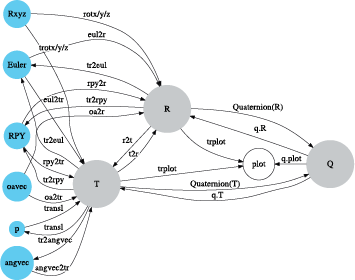


Convert the resulting rotation matrix back to ZYZ Euler angles with `tr2eul`.

In [ ]:
Rzyz = tr2eul(R0)
print(Rzyz)

### Surjective (many-to-one) mappings

A three-angle parameterization is not globally one-to-one: different angle triples can represent the same physical orientation. The exact representative returned by the inverse mapping depends on the toolbox's branch conventions.

Start with a negative middle Euler angle.

In [ ]:
Rzyz_1 = np.array([0.1, -0.2, 0.3])
R1 = eul2r(*Rzyz_1)
print('Original Euler angles:', Rzyz_1)
print('Rotation matrix R1:\n', R1)


Convert the matrix back to Euler angles.

In [ ]:
Rzyz_2 = tr2eul(R1)
print('Recovered representative:', Rzyz_2)


Reconstruct a rotation matrix from the recovered angles. Although the angle triples differ, the rotations are equivalent.

In [ ]:
R2 = eul2r(*Rzyz_2)
print('R1 == R2:', np.allclose(R1, R2, atol=1e-10))


### (ii) Roll–Pitch–Yaw angles

Create an RPY rotation with angles 0.1, 0.2, and 0.3 rad.

In [ ]:
R3 = rpy2r(0.1, 0.2, 0.3)
print(R3)

This is not the same as the ZYZ Euler rotation using the same three numbers because the axis sequence is different.

In [ ]:
print('R0 =\n', R0)
print('\nR3 =\n', R3)
print('\nR0 == R3:', np.allclose(R0, R3, atol=1e-10))


Map the matrix back to RPY angles.

In [ ]:
print(tr2rpy(R3))

The class interface offers the same ideas with typed `SO3` objects.

In [ ]:
R_obj = SO3.RPY([0.1, 0.2, 0.3])
print(R_obj)
print('RPY recovered:', R_obj.rpy())


### Gimbal Lock

For the default ZYX RPY convention, pitch at $\pm 90^\circ$ is singular. At the singularity, two of the rotational degrees of freedom become coupled, so roll and yaw cannot be independently recovered.

The MATLAB notebook demonstrates this interactively with `tripleangle`. In Python we can make the same loss of uniqueness explicit numerically.

In [ ]:
R_lock = rpy2r(0.3, pi/2, 0.5)
print('Rotation matrix at pitch = 90 deg:\n', R_lock)
print('\nOne inverse RPY representative:', tr2rpy(R_lock))


At pitch = +90°, adding the same offset to roll and yaw produces the same rotation. That is the lost degree of freedom.

In [ ]:
delta = 0.4
R_lock_2 = rpy2r(0.3 + delta, pi/2, 0.5 + delta)
print('Equivalent rotation?', np.allclose(R_lock, R_lock_2, atol=1e-10))


---

## Lec 02.11 (Ch 2.2) — Angle–Axis Representation

The final rotation-matrix property emphasized in the MATLAB notebook is its eigenstructure:

8. A proper 3D rotation matrix has a real eigenvalue of **+1**. The corresponding eigenvector gives the **axis of rotation**.

For a rotation matrix $R$, the rotation angle can also be obtained from its trace:

$$
\mathrm{trace}(R)=1+2\cos	heta,
\qquad
	heta=\cos^{-1}\left(rac{\mathrm{trace}(R)-1}{2}ight).
$$


The MATLAB live script includes the following geometric illustration near this discussion:

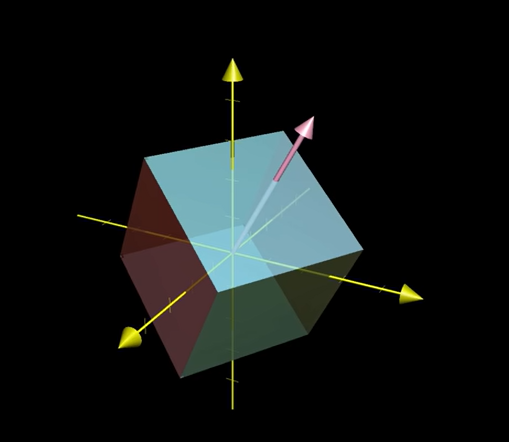


Create a compound rotation matrix.

In [ ]:
R = eul2r(pi/2, pi/2, 0)
print(R)

In [ ]:
fig, ax = new_3d_axes()
trplot(np.eye(3), frame='{W}', color='k', ax=ax)
trplot(R, frame='{A}', color='b', ax=ax)
plt.show()


### Eigenvectors and eigenvalues

NumPy returns the eigenvalues as a vector and the corresponding eigenvectors as columns of a matrix.

In [ ]:
eig_val, eig_vec = np.linalg.eig(R)
print('Eigenvalues:')
print(eig_val)
print('\nEigenvectors (columns):')
print(eig_vec)


Find the eigenvalue closest to +1 and extract its eigenvector as the rotation axis.

In [ ]:
idx = np.argmin(np.abs(eig_val - 1.0))
axis_from_eig = np.real(eig_vec[:, idx])
axis_from_eig /= np.linalg.norm(axis_from_eig)

print('Eigenvalue closest to +1:', eig_val[idx])
print('Axis from eigenvector:', axis_from_eig)


The Spatial Math Toolbox performs the equivalent conversion directly with `tr2angvec`.

In [ ]:
theta, axis = tr2angvec(R)
print('Rotation angle [rad]:', theta)
print('Rotation axis:', axis)


Check the trace formula independently.

In [ ]:
theta_trace = np.arccos(np.clip((np.trace(R) - 1) / 2, -1.0, 1.0))
print('Angle from trace [rad]:', theta_trace)
print('Matches tr2angvec:', np.isclose(theta, theta_trace))


Try simple 90° rotations around the principal axes. The returned axes should be intuitive.

In [ ]:
for name, Ri in [('Rx', rotx(pi/2)), ('Ry', roty(pi/2)), ('Rz', rotz(pi/2))]:
    th, vec = tr2angvec(Ri)
    print(f'{name}: theta={th:.5f}, axis={vec}')


### Rodrigues' equation: angle-axis → rotation matrix

Map the angle-axis result back to a rotation matrix with `angvec2r`.

In [ ]:
R_reconstructed = angvec2r(theta, axis)
print(R_reconstructed)
print('\nMatches original R:', np.allclose(R, R_reconstructed, atol=1e-10))


The object-oriented equivalent is `SO3.AngVec`.

In [ ]:
R_angvec_obj = SO3.AngVec(theta, axis)
print(R_angvec_obj)
print('Angle-axis from object:', R_angvec_obj.angvec())


---

## Lec 02.12 (Ch 2.2) — Unit Quaternions

Before going deeply into quaternion exercises, the MATLAB live script recommends Ben Eater and Grant Sanderson's interactive introduction:

https://eater.net/quaternions

A unit quaternion represents 3D orientation with four numbers constrained to unit norm. It is compact, composes efficiently, and avoids the gimbal-lock singularity of three-angle parameterizations (although it is a double-cover: $q$ and $-q$ represent the same rotation).


### Unit Quaternion Instantiation

Start from the identity rotation matrix and convert it to a `UnitQuaternion`.

In [ ]:
R0 = np.eye(3)
q0 = UnitQuaternion(R0)
print(q0)
print('scalar s =', q0.s)
print('vector v =', q0.v)


Create 90° and 180° rotations about z, then convert them to unit quaternions.

In [ ]:
Rz90 = rotz(pi/2)
Rz180 = rotz(pi)

q90 = UnitQuaternion(Rz90)
q180 = UnitQuaternion(Rz180)

print('q90 =', q90)
print('q180 =', q180)


### Instantiating directly from scalar and vector parts

For a 90° z-rotation, $s=\cos(45^\circ)=\sqrt{2}/2$ and $v=[0,0,\sin(45^\circ)]$. In Python the quaternion can be given as `[s, vx, vy, vz]`.

In [ ]:
s = np.sqrt(2) / 2
v = np.array([0.0, 0.0, s])
q90_direct = UnitQuaternion([s, *v])
print(q90_direct)
print('Equivalent to q90:', q90_direct == q90)


You can animate a unit quaternion's orientation. This is left as an optional interactive call because notebook backends vary.

In [ ]:
# Optional interactive animation:
# q90.animate()


### Relationship between angle-axis and unit quaternions

For rotation angle $\theta$ about unit axis $\hat n$:

$$
s = \cos\frac{\theta}{2},
\qquad
v = \hat n\sin\frac{\theta}{2}.
$$

For a 90° rotation about x, $\hat n=[1,0,0]$.

In [ ]:
th_x90, vec_x90 = tr2angvec(rotx(pi/2))
q_x90 = UnitQuaternion(rotx(pi/2))

print('angle-axis:', th_x90, vec_x90)
print('cos(theta/2) =', np.cos(pi/4))
print('sin(theta/2) =', np.sin(pi/4))
print('quaternion =', q_x90)


Now repeat for a 180° x-rotation.

In [ ]:
th_x180, vec_x180 = tr2angvec(rotx(pi))
q_x180 = UnitQuaternion(rotx(pi))

print('angle-axis:', th_x180, vec_x180)
print('cos(theta/2) =', np.cos(pi/2))
print('sin(theta/2) =', np.sin(pi/2))
print('quaternion =', q_x180)


### Compounding unit-quaternion rotations

Quaternion multiplication compounds rotations. Multiplying a 90° z-rotation by itself should give a 180° z-rotation.

In [ ]:
q180_2 = q90 * q90
print('q90 * q90 =', q180_2)
print('expected q180 =', q180)
print('Equivalent:', q180_2 == q180)


Convert the compounded quaternion to a rotation matrix.

In [ ]:
print(q180_2.R)

The conjugate of a unit quaternion is its inverse rotation.

In [ ]:
q_identity = q90 * q90.conj()
print(q_identity)
print('norm(q90)  =', q90.norm())
print('norm(q180) =', q180.norm())


Convert a unit quaternion to other orientation representations.

In [ ]:
print('SO3 object:')
print(q90.SO3())

print('\nSE3 object with zero translation:')
print(q90.SE3())

print('\nAngle-axis:', q90.angvec())
print('Euler ZYZ:', q90.eul())
print('RPY:', q90.rpy())
print('\nHomogeneous transform matrix:\n', q90.SE3().A)


### Quaternion-vector product

A 90° rotation about z applied to a vector pointing along +x should produce a vector along +y.

In [ ]:
x_hat = np.array([1.0, 0.0, 0.0])
y_hat = q90 * x_hat
print(y_hat)


---

# Consolidated 3D Pose Extension — Translation + Orientation with `SE3`

The MATLAB live script ends with a TODO about composing position and orientation in homogeneous transforms. The older `3.13.ipynb` contains exactly that material, so it is incorporated here to complete the 3D-pose story.

An `SE3` object represents a rigid-body pose/motion: **3D rotation + 3D translation** in a 4×4 homogeneous transformation.


### Pure translation

Create a translation of one unit along x.

In [ ]:
T1 = SE3.Tx(1)
print(T1)


In [ ]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
SE3().plot(frame='0', dims=[-3, 3], color='k', ax=ax)
T1.plot(frame='1', color='b', ax=ax)
plt.show()


Compose two identical translations. For Spatial Math pose objects, `*` is the group-composition operator.

In [ ]:
T2 = T1 * T1
print(T2)
print('Same as T1**2:', T2 == T1**2)


Translations along all three axes can be created directly.

In [ ]:
print(SE3.Tz(4))
print(SE3.Ty(3))
print(SE3.Trans(7, 8, 9))


A motion followed by its inverse is the identity pose.

In [ ]:
Ty2 = SE3.Ty(2)
print(Ty2.inv())
print('\nTy2 * Ty2.inv() =')
print(Ty2 * Ty2.inv())


### Transforming a point

If a point is expressed in a local frame, premultiplying it by an `SE3` pose gives its coordinates in the parent/world frame.

In [ ]:
P = np.array([1.0, 2.0, 3.0])
T = SE3.Trans(4, 5, 6)
print(T * P)


### Combining translation and rotation

Construct a pose with translation `(1,2,3)` and a 30° x-rotation.

In [ ]:
T1 = SE3.Trans(1, 2, 3) * SE3.Rx(30, unit='deg')
print(T1)


The order matters. For a point vector, the rightmost factor acts first:

- `SE3.Trans(...) * SE3.Rx(...)` rotates the point first, then translates it.
- `SE3.Rx(...) * SE3.Trans(...)` translates first, then rotates the translated point about the origin.


In [ ]:
T2 = SE3.Rx(30, unit='deg') * SE3.Trans(1, 2, 3)
print(T2)
print('\nSame pose?', T1 == T2)


In [ ]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
SE3().plot(frame='0', dims=[-1, 4], color='k', ax=ax)
T1.plot(frame='1', color='b', ax=ax)
T2.plot(frame='2', color='r', ax=ax)
plt.show()


Transform a point from frame `{1}` into the world frame, then use the inverse to map it back.

In [ ]:
P_1 = np.array([1.0, 2.0, 1.0])
P_W = T1 * P_1
P_1_recovered = T1.inv() * P_W

print('P in frame {1}:', P_1)
print('P in world frame:', P_W.ravel() if hasattr(P_W, 'ravel') else P_W)
print('Recovered:', P_1_recovered.ravel() if hasattr(P_1_recovered, 'ravel') else P_1_recovered)


Extract the orientation and translation components of an `SE3` pose.

In [ ]:
print('Rotation R =\n', T1.R)
print('\nTranslation t =', T1.t)
print('\nFrame-axis columns n, o, a:')
print('n =', T1.n)
print('o =', T1.o)
print('a =', T1.a)


### Transforming multiple points

Spatial Math treats columns of a 3×N array as points. Here the columns are the eight vertices of a cube.

In [ ]:
P = np.array([
    [-1,  1,  1, -1, -1,  1,  1, -1],
    [-1, -1,  1,  1, -1, -1,  1,  1],
    [-1, -1, -1, -1,  1,  1,  1,  1],
], dtype=float)

Tcube = SE3.Rx(90, unit='deg')
Q = Tcube * P
print(Q)


Plot the original and transformed cube vertices.

In [ ]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(P[0], P[1], P[2], label='Original')
ax.scatter(Q[0], Q[1], Q[2], label='Rotated')

edges = [
    (0,1),(1,2),(2,3),(3,0),
    (4,5),(5,6),(6,7),(7,4),
    (0,4),(1,5),(2,6),(3,7),
]
for i, j in edges:
    ax.plot(P[0,[i,j]], P[1,[i,j]], P[2,[i,j]], alpha=0.5)
    ax.plot(Q[0,[i,j]], Q[1,[i,j]], Q[2,[i,j]], alpha=0.5)

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_box_aspect((1,1,1))
ax.legend()
plt.show()


### Optional: sequences of poses

Spatial Math pose classes can hold multiple values, which is useful for trajectories and sampled orientations. This material comes from the older `3.13.ipynb` and is retained as an optional extension.


In [ ]:
Tseq = SE3.Rx(np.linspace(0, 0.5, 5))
print('number of poses:', len(Tseq))
print('\nthird indexed pose Tseq[3]:')
print(Tseq[3])


In [ ]:
T_offset = SE3.Ry(40, unit='deg')
A = Tseq * T_offset
B = T_offset * Tseq

print('len(Tseq * T_offset) =', len(A))
print('len(T_offset * Tseq) =', len(B))


In [ ]:
Pseq = Tseq * [0, 1, 0]
print(Pseq)


---

## MATLAB → Python quick-reference table

| MATLAB live-script call | Python equivalent used here |
|---|---|
| `eye(3)` | `np.eye(3)` |
| `rotx(a)`, `roty(a)`, `rotz(a)` | same names from `spatialmath.base` |
| `R1 * R2` (raw matrices) | `R1 @ R2` |
| `R'` | `R.T` |
| `inv(R)` | `np.linalg.inv(R)` |
| `det(R)` | `np.linalg.det(R)` |
| `r2t(R)` | `r2t(R)` |
| `trotx`, `troty`, `trotz` | same names from `spatialmath.base` |
| `trplot(R,...)` | `trplot(R,...)` |
| `eul2r` / `tr2eul` | same names |
| `rpy2r` / `tr2rpy` | same names |
| `eig(R)` | `np.linalg.eig(R)` |
| `tr2angvec` / `angvec2r` | same names |
| `UnitQuaternion(R)` | `UnitQuaternion(R)` |
| `q.s`, `q.v` | same properties |
| `q1*q2` | same composition operator |
| `q.conj` | `q.conj()` |
| `q.norm` | `q.norm()` |
| `q.R` | same rotation-matrix property |
| `q.SE3` | `q.SE3()` |
| `q.toangvec` | `q.angvec()` |
| `q.toeul` | `q.eul()` |
| `q.torpy` | `q.rpy()` |
| `q*[x,y,z]'` | `q * np.array([x,y,z])` |
| MATLAB homogeneous pose | `SE3` object |
| pose composition | `T1 * T2` |
| pose inverse | `T.inv()` |
| pose rotation/translation | `T.R`, `T.t` |

### Core takeaways

- `SO3` represents **orientation only**.
- `SE3` represents a complete **3D rigid-body pose**: orientation + position.
- Euler and RPY angles are compact but have singularities and non-unique inverse mappings.
- Angle-axis gives a geometric rotation axis and amount.
- Unit quaternions are compact and well suited to composition/interpolation, but use a double-cover of SO(3).
- Transform composition is order-dependent; label coordinate frames explicitly.
